In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path

import ray
import torch
from torch.utils.data import DataLoader
import pytorch_lightning as pl
from numpy.random import default_rng
from pytorch_lightning.callbacks import ModelCheckpoint
from pytorch_lightning.loggers import WandbLogger
import wandb

In [3]:
import sys
sys.path.append("../")
sys.path.append("../../recurrently_predicting_hypergraphs/")

from convex_hull_dataset import get_ch_dl, ConvexHullData
import misc
import metrics

In [4]:
# Dataset
D_FEATS = 3
N_POINTS = torch.arange(30,31)
UNIT_NORM = False

# Model hyperparameter
CONFIG = "../configs/hgflow.yaml"
TRAIN = "../configs/train.yaml"

# Training hyperparameter
BATCH_SIZE = 64
LR = 0.0003
N_EPOCHS = 1000

# Miscellaneous
SEED = 123456
RNG = default_rng(SEED)
pl.seed_everything(SEED)
N_RAY = 0
if N_RAY > 0:
    ray.init(num_cpus=N_RAY,include_dashboard=False)

Global seed set to 123456


In [5]:
def get_collate_fn(max_facets, add_indicator=False, max_points=None):

    def pad(x, max_points):
        if max_points is None:
            return x
        delta = max_points - x.size(0)
        if delta > 0:
            x = torch.cat([x, torch.full((delta, x.size(1)), float('nan'))], dim=0)
        elif delta < 0:
            raise ValueError("max_points is smaller than the number of points!")
        return x

    if not add_indicator:
        def collate_fn(batch):
            points = []
            incidence = []
            for p, i in batch:
                points.append(pad(p, max_points))
                incidence.append(torch.cat([i, torch.zeros(max_facets - i.size(0), i.size(1))],dim=0))
            return torch.stack(points), torch.stack(incidence)
        return collate_fn
    else:
        def collate_fn(batch):
            points = []
            incidence = []
            for p, i in batch:
                nf = i.size(0)
                inc = torch.cat([i, torch.zeros(max_facets - nf, i.size(1))],dim=0)
                inc = torch.cat([inc, torch.zeros(max_facets, 1)], dim=1)
                inc[:nf,-1] = 1.
                incidence.append(inc)
                points.append(pad(p, max_points))
            return torch.stack(points), torch.stack(incidence)
        return collate_fn

In [6]:
train_dataset = ConvexHullData(n_range=N_POINTS,dim=D_FEATS,unit_norm=UNIT_NORM,length=20000)
collate_fn = get_collate_fn(max_facets=train_dataset.max_facets, add_indicator=True, max_points=train_dataset.max_points)
trainloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, collate_fn=collate_fn, shuffle=True, num_workers=0)

In [7]:
val_dataset = ConvexHullData(n_range=N_POINTS,dim=D_FEATS,unit_norm=UNIT_NORM,length=2000)
valloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, collate_fn=collate_fn, shuffle=False, num_workers=0)

In [8]:
for example in valloader:
    x, y  = example
    break

In [9]:
x = x[0]
y = y[0]

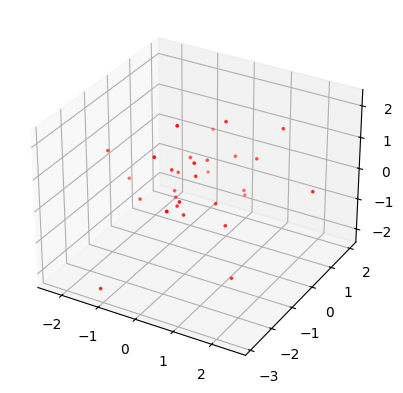

In [10]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x[:, 0], x[:, 1], x[:, 2], s=3, c='r', marker='o')
plt.show()

In [11]:
y[:,-1]

tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.])

In [12]:
print("Number of hyperedges per point:")
print(y[:,:-1].sum(axis=0))
print("Number of points per hyperedge:")
print(y[:,:-1].sum(axis=1))

Number of hyperedges per point:
tensor([5., 0., 0., 5., 7., 0., 3., 0., 4., 0., 0., 3., 0., 0., 0., 5., 0., 0.,
        0., 4., 7., 0., 5., 0., 0., 5., 0., 0., 6., 7.])
Number of points per hyperedge:
tensor([3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3.,
        3., 3., 3., 3., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.])


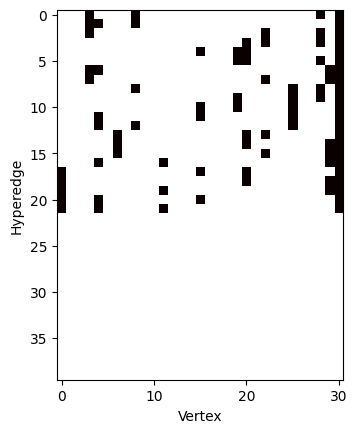

In [13]:
fig, ax = plt.subplots()
ax.imshow(1- y.unsqueeze(-1), cmap='hot')
ax.set_ylabel("Hyperedge")
ax.set_xlabel("Vertex")
plt.show()

In [14]:
from lights.hgflow_lightning import HGFlowLightning

In [15]:
model = HGFlowLightning(
    model_config=CONFIG,
    train_config=TRAIN,
)

In [16]:
data_type = "spherical" if UNIT_NORM else "normal"
wandb.init(
    settings=wandb.Settings(start_method='spawn'),
    name=f"Transformer P{N_POINTS[0]}to{N_POINTS[-1]}",
    project=f"log_convex_hull_{data_type}",
    reinit=False,
)
logger = WandbLogger(
    log_model=True,
)
checkpoint_callback = ModelCheckpoint(
    monitor='loss/val',
    mode='min',
)

wandb: Currently logged in as: etienne-dreyer (etienne-dreyer-weizmann-institute-of-science) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


/Users/ets/miniconda3/envs/torchmetal/lib/python3.12/site-packages/pytorch_lightning/loggers/wandb.py:395: UserWarning: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
  rank_zero_warn(


In [17]:
trainer = pl.Trainer(
    accelerator="mps",
    devices=1,
    max_epochs=N_EPOCHS,
    logger=logger,
    callbacks=[checkpoint_callback],
)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


In [18]:
trainer.fit(model, trainloader, valloader)


  | Name | Type   | Params
--------------------------------
0 | net  | HGFlow | 830 K 
--------------------------------
830 K     Trainable params
0         Non-trainable params
830 K     Total params
3.321     Total estimated model params size (MB)


Sanity Checking: 0it [00:00, ?it/s]

/Users/ets/miniconda3/envs/torchmetal/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:224: PossibleUserWarning: The dataloader, val_dataloader 0, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 8 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(
/Users/ets/miniconda3/envs/torchmetal/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:224: PossibleUserWarning: The dataloader, train_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 8 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


Training: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

...

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

/Users/ets/miniconda3/envs/torchmetal/lib/python3.12/site-packages/pytorch_lightning/trainer/call.py:48: UserWarning: Detected KeyboardInterrupt, attempting graceful shutdown...
  rank_zero_warn("Detected KeyboardInterrupt, attempting graceful shutdown...")


Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x177243530>> (for post_run_cell), with arguments args (<ExecutionResult object at 31153b200, execution_count=18 error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 31153b290, raw_cell="trainer.fit(model, trainloader, valloader)" store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/ets/Weizmann%20Institute%20Dropbox/Etienne%20Dreyer/WIS/HyperGraphFlow/hypergraphflow/notebooks/convex_hull_custom.ipynb#X13sZmlsZQ%3D%3D> result=None>,),kwargs {}:


BrokenPipeError: [Errno 32] Broken pipe